In [5]:
!pip install torch torchvision opencv-python matplotlib seaborn tqdm


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

Device: cuda
GPU: NVIDIA GeForce RTX 3060 Ti


In [2]:
import os
import cv2
import torch
import random
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as F
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from tqdm import tqdm

In [11]:
%pip install tqdm

  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
Note: you may need to restart the kernel to use updated packages.


In [4]:
dataset_path = r"C:\Users\ikozi\Downloads\Telegram Desktop\content\fish_dataset_2\Fish Detection Dataset"

train_images = f"{dataset_path}/train/images"
train_labels = f"{dataset_path}/train/labels"

val_images = f"{dataset_path}/valid/images"
val_labels = f"{dataset_path}/valid/labels"

test_images = f"{dataset_path}/test/images"
test_labels = f"{dataset_path}/test/labels"

In [5]:
class FishDataset(Dataset):

    def __init__(self, images_dir, labels_dir):
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.images = os.listdir(images_dir)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img_name = self.images[idx]

        img_path = os.path.join(self.images_dir, img_name)
        label_path = os.path.join(self.labels_dir, img_name.replace(".jpg",".txt"))

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        h, w, _ = image.shape

        boxes = []
        labels = []

        if os.path.exists(label_path):

            with open(label_path) as f:
                lines = f.readlines()

            for line in lines:

                cls, x, y, bw, bh = map(float, line.split())

                xmin = (x - bw/2) * w
                ymin = (y - bh/2) * h
                xmax = (x + bw/2) * w
                ymax = (y + bh/2) * h

                boxes.append([xmin, ymin, xmax, ymax])
                labels.append(1)

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)

        target = {}
        target["boxes"] = boxes
        target["labels"] = labels

        image = F.to_tensor(image)

        return image, target

In [6]:
def collate_fn(batch):
    return tuple(zip(*batch))

train_dataset = FishDataset(train_images, train_labels)
val_dataset = FishDataset(val_images, val_labels)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=collate_fn
)

In [7]:
num_classes = 2

model = fasterrcnn_resnet50_fpn(weights="DEFAULT")

in_features = model.roi_heads.box_predictor.cls_score.in_features

model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
    in_features,
    num_classes
)

model.to(device)

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [8]:
params = [p for p in model.parameters() if p.requires_grad]

optimizer = torch.optim.Adam(
    params,
    lr=0.0001
)

In [9]:
num_epochs = 20

for epoch in range(num_epochs):

    model.train()
    epoch_loss = 0

    for images, targets in tqdm(train_loader):

        images = [img.to(device) for img in images]
        targets = [{k:v.to(device) for k,v in t.items()} for t in targets]

        loss_dict = model(images, targets)

        loss = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch {epoch+1} Loss {epoch_loss:.4f}")

100%|████████████████████████████████████████████████████████████████████████████████| 738/738 [05:43<00:00,  2.15it/s]


Epoch 1 Loss 175.0372


100%|████████████████████████████████████████████████████████████████████████████████| 738/738 [06:32<00:00,  1.88it/s]


Epoch 2 Loss 129.4339


100%|████████████████████████████████████████████████████████████████████████████████| 738/738 [06:41<00:00,  1.84it/s]


...

Epoch 18 Loss 30.2306


100%|████████████████████████████████████████████████████████████████████████████████| 738/738 [05:59<00:00,  2.05it/s]


Epoch 19 Loss 28.6263


100%|████████████████████████████████████████████████████████████████████████████████| 738/738 [05:51<00:00,  2.10it/s]

Epoch 20 Loss 26.5340


In [10]:
torch.save(model.state_dict(), "fish_resnet_detector.pth")

In [11]:
model.eval()

img_path = random.choice(os.listdir(test_images))

img = cv2.imread(os.path.join(test_images,img_path))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

tensor = F.to_tensor(img_rgb).to(device)

with torch.no_grad():
    preds = model([tensor])

(np.float64(-0.5), np.float64(415.5), np.float64(415.5), np.float64(-0.5))

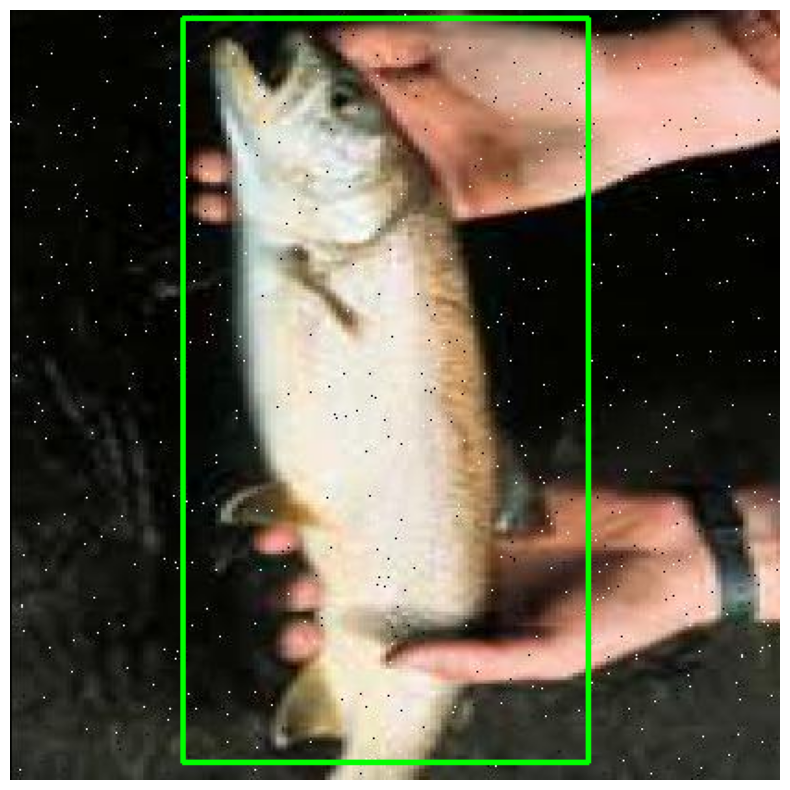

In [12]:
boxes = preds[0]["boxes"].cpu().numpy()
scores = preds[0]["scores"].cpu().numpy()

for box,score in zip(boxes,scores):

    if score < 0.5:
        continue

    x1,y1,x2,y2 = box.astype(int)

    cv2.rectangle(img,(x1,y1),(x2,y2),(0,255,0),2)

plt.figure(figsize=(10,10))
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.axis("off")

In [14]:
import torch

def compute_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    interArea = max(0, xB - xA) * max(0, yB - yA)

    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    union = boxAArea + boxBArea - interArea

    if union == 0:
        return 0

    return interArea / union

In [15]:
def calculate_precision_recall(model, dataloader, device, iou_threshold=0.5, score_threshold=0.5):

    model.eval()

    TP = 0
    FP = 0
    FN = 0

    with torch.no_grad():

        for images, targets in dataloader:

            images = [img.to(device) for img in images]

            outputs = model(images)

            for i in range(len(outputs)):

                pred_boxes = outputs[i]["boxes"].cpu()
                pred_scores = outputs[i]["scores"].cpu()

                gt_boxes = targets[i]["boxes"].cpu()

                matched = set()

                for p_box, score in zip(pred_boxes, pred_scores):

                    if score < score_threshold:
                        continue

                    best_iou = 0
                    best_gt = -1

                    for j, gt_box in enumerate(gt_boxes):

                        iou = compute_iou(p_box, gt_box)

                        if iou > best_iou:
                            best_iou = iou
                            best_gt = j

                    if best_iou >= iou_threshold and best_gt not in matched:
                        TP += 1
                        matched.add(best_gt)
                    else:
                        FP += 1

                FN += len(gt_boxes) - len(matched)

    precision = TP / (TP + FP + 1e-6)
    recall = TP / (TP + FN + 1e-6)

    return precision, recall

In [16]:
precision, recall = calculate_precision_recall(
    model,
    val_loader,
    device
)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

Precision: 0.8872
Recall: 0.8092
